# Soft information decoding

A superconducting qubit readout returns an analog point μ in the IQ plane, not a bit. A hard decoder
thresholds μ and forgets how sure that call was. A soft decoder keeps it as a soft flip probability
p_s(μ) and reweights the matching graph shot by shot.

This notebook walks through the `softinfo` package on real calibration data of IBM Sherbrooke qubit 72
(shipped in `data/iq_figures.npz`, no download needed):

1. readout: IQ point → outcome and p_s(μ), and leakage
2. the repetition code circuit
3. soft vs hard decoding of simulated memories
4. how many bits of p_s are needed
5. the published hardware results

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from softinfo import Noise, Readout, SoftMatcher, postselect, repetition_code, truncate
from softinfo.data import unpack

plt.rcParams.update({"figure.dpi": 200, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(0)

## 1. Readout

In a calibration run the qubit is prepared in |0⟩ and |1⟩ and measured twice. A shot that is wrong in
both measurements had its state flipped before readout (a hard flip, e.g. T1 decay), so `postselect`
drops it and the clouds describe the readout alone.

kept 15612 of 15748 |0⟩ shots and 15446 of 15748 |1⟩ shots


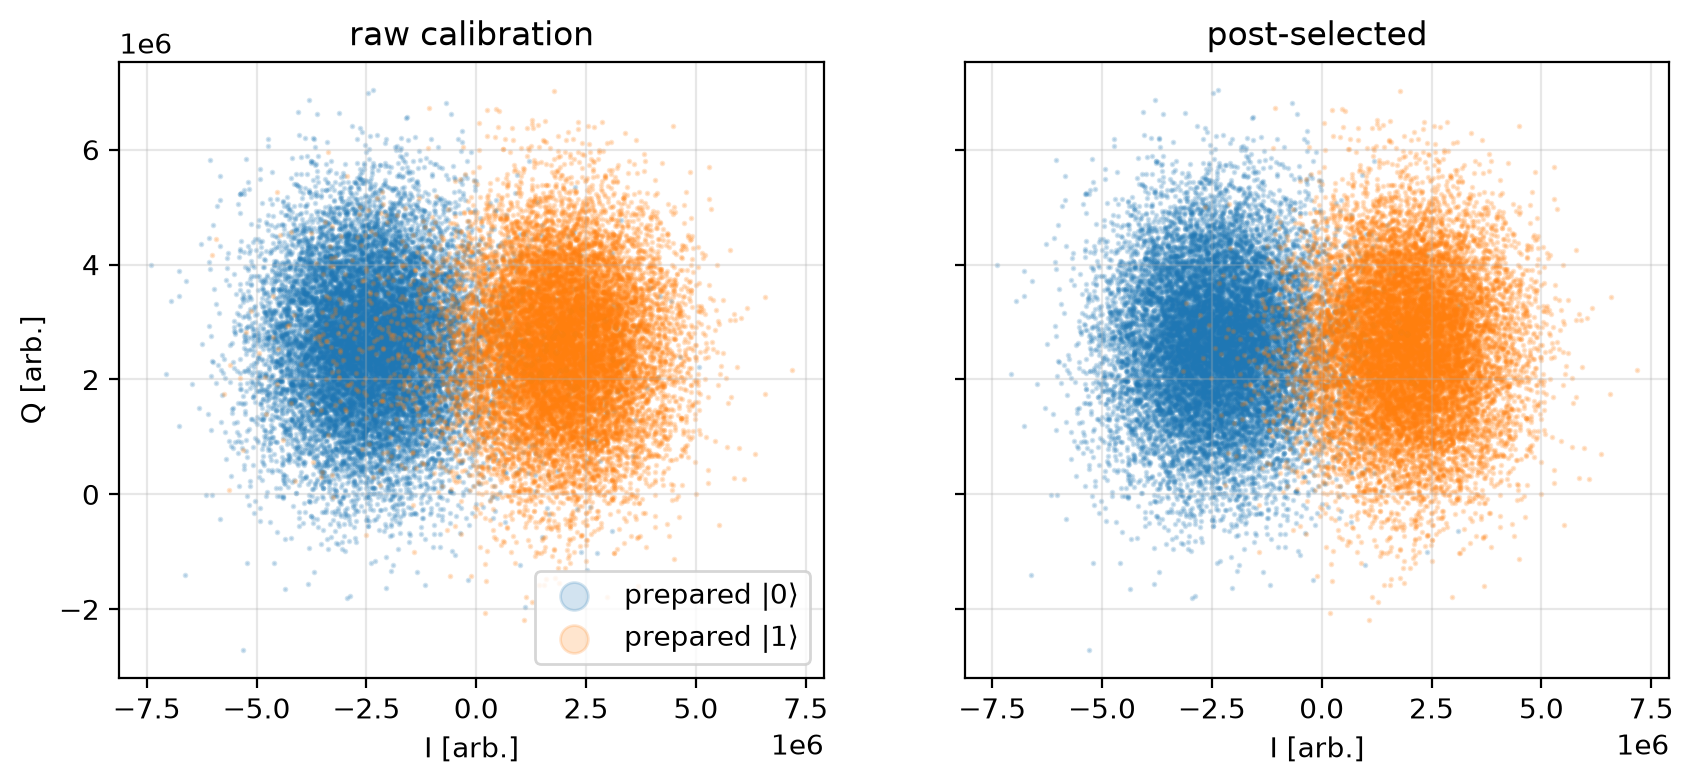

In [2]:
f = np.load("../data/iq_figures.npz")
first0, second0, first1, second1 = (unpack(f, f"cal_q72_{k}") for k in ("first0", "second0", "first1", "second1"))
iq0, iq1 = postselect(first0, second0, first1, second1)
print(f"kept {len(iq0)} of {len(first0)} |0⟩ shots and {len(iq1)} of {len(first1)} |1⟩ shots")

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, (a, b), title in [(axs[0], (first0, first1), "raw calibration"), (axs[1], (iq0, iq1), "post-selected")]:
    ax.scatter(a.real, a.imag, s=1, alpha=0.2, label="prepared |0⟩")
    ax.scatter(b.real, b.imag, s=1, alpha=0.2, label="prepared |1⟩")
    ax.set(title=title, xlabel="I [arb.]")
axs[0].set_ylabel("Q [arb.]")
axs[0].legend(markerscale=10);

`Readout` fits a kernel density estimate f₀, f₁ to each cloud. For a measured point μ it returns the
likelier outcome and

p_s(μ) = min(f₀, f₁) / (f₀ + f₁),

which is about 0 deep inside a cloud and 0.5 on the decision boundary (white line). Points far from both
clouds are flagged as leaked and get p_s = 0.5 (left, outer region). Right: the 200 000 outcomes of this
qubit in a real repetition code run, colored by p_s.

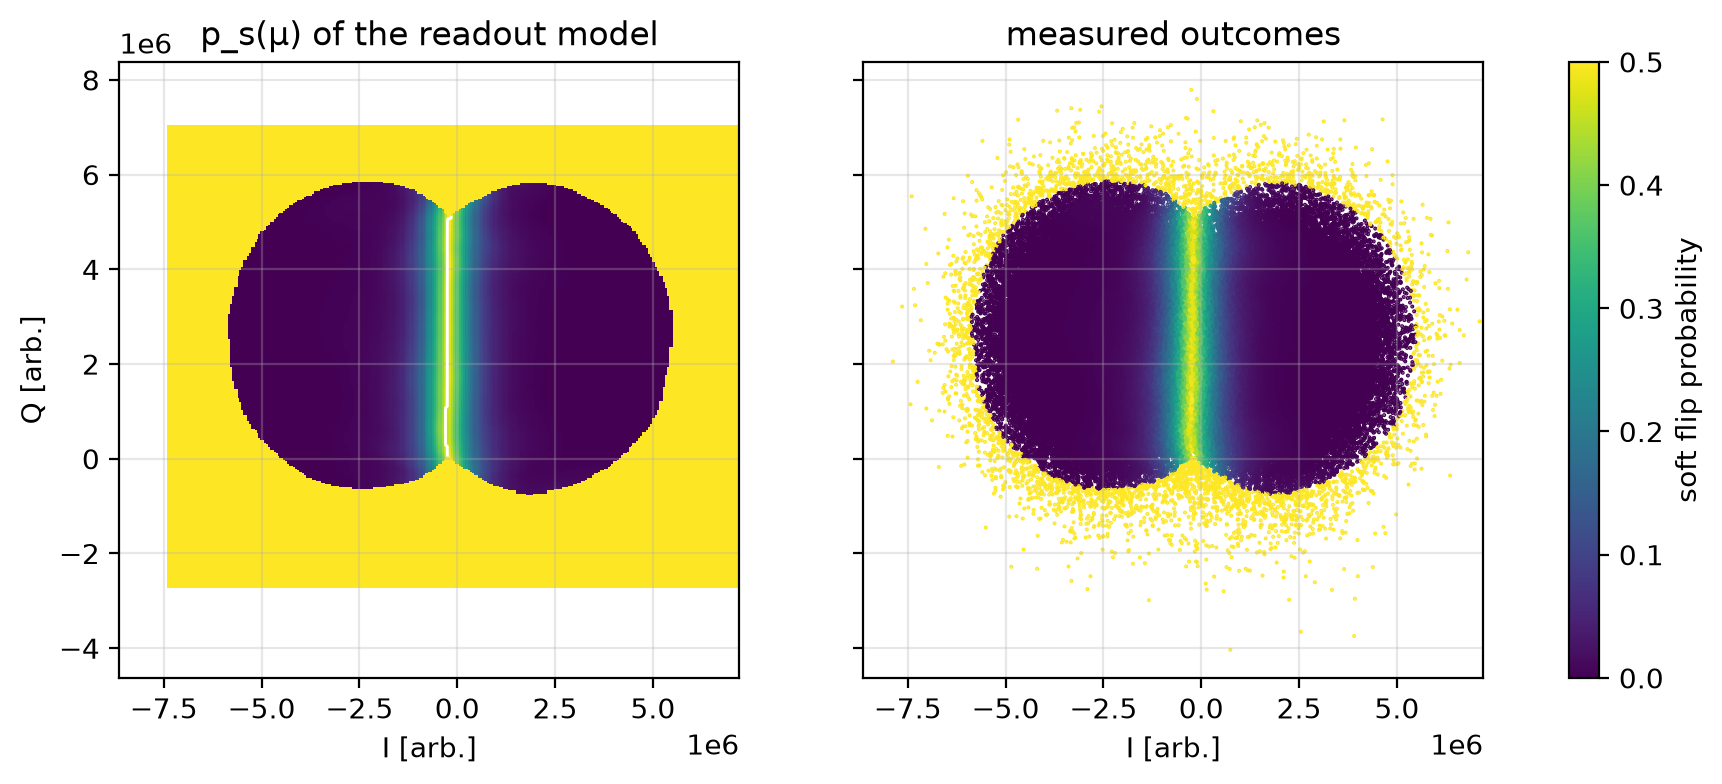

In [3]:
readout = Readout(iq0, iq1)
both = np.concatenate([iq0, iq1])
I, Q = np.meshgrid(np.linspace(both.real.min(), both.real.max(), 300), np.linspace(both.imag.min(), both.imag.max(), 300))
z_grid, p_grid = readout(I + 1j * Q)
measured = unpack(f, "exp_q72").ravel()
z, p = readout(measured)

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
im = axs[0].pcolormesh(I, Q, p_grid, cmap="viridis", vmin=0, vmax=0.5)
axs[0].contour(I, Q, np.where(readout.leaked(I + 1j * Q), np.nan, z_grid), levels=[0.5], colors="w", linewidths=1)
axs[1].scatter(measured.real, measured.imag, c=p, cmap="viridis", vmin=0, vmax=0.5, s=0.2, rasterized=True)
axs[0].set(title="p_s(μ) of the readout model", xlabel="I [arb.]", ylabel="Q [arb.]")
axs[1].set(title="measured outcomes", xlabel="I [arb.]")
fig.colorbar(im, ax=axs, label="soft flip probability");

Almost every outcome is certain, but a tail is ambiguous. A hard decoder treats all of them alike.

mean p_s 0.0555, outcomes with p_s > 0.1: 15.71%, leaked: 1.783%


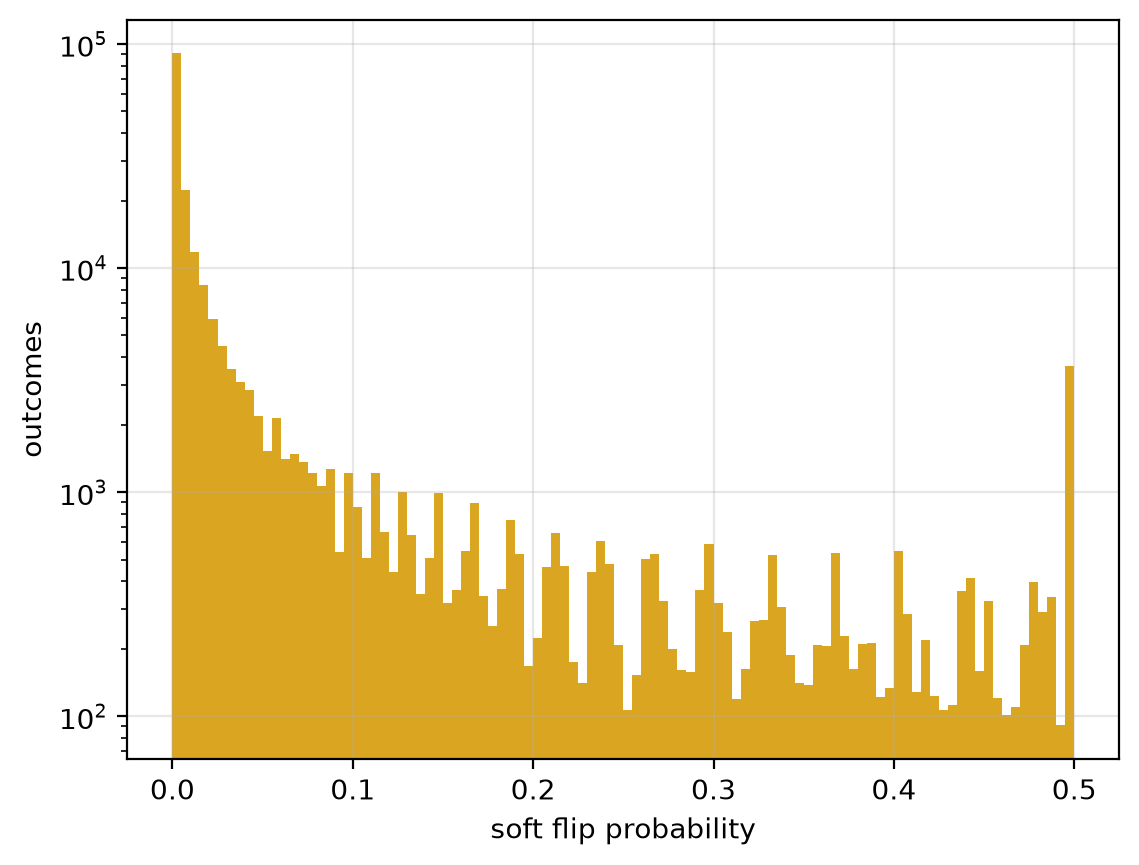

In [4]:
print(f"mean p_s {p.mean():.4f}, outcomes with p_s > 0.1: {(p > 0.1).mean():.2%}, leaked: {(p == 0.5).mean():.3%}")
plt.hist(p, bins=100, log=True, color="goldenrod")
plt.gca().set(xlabel="soft flip probability", ylabel="outcomes");

### Leakage

Over a long run some qubits leak out of the computational subspace into |2⟩, which shows up as a third
cloud that the calibration never saw. Qubit 3 measured 100 times per shot (15 360 shots) shows it
clearly. Both calibration densities are tiny there, so `Readout` flags these points as leaked and gives
them p_s = 0.5: the decoder learns nothing from them instead of trusting a wrong 0 or 1. The rule also
catches the far tails of the |0⟩ and |1⟩ clouds. The leaked fraction grows from about 1 % to 10 % over
the run as leakage accumulates, then saturates.

leaked: 8.0% of all outcomes


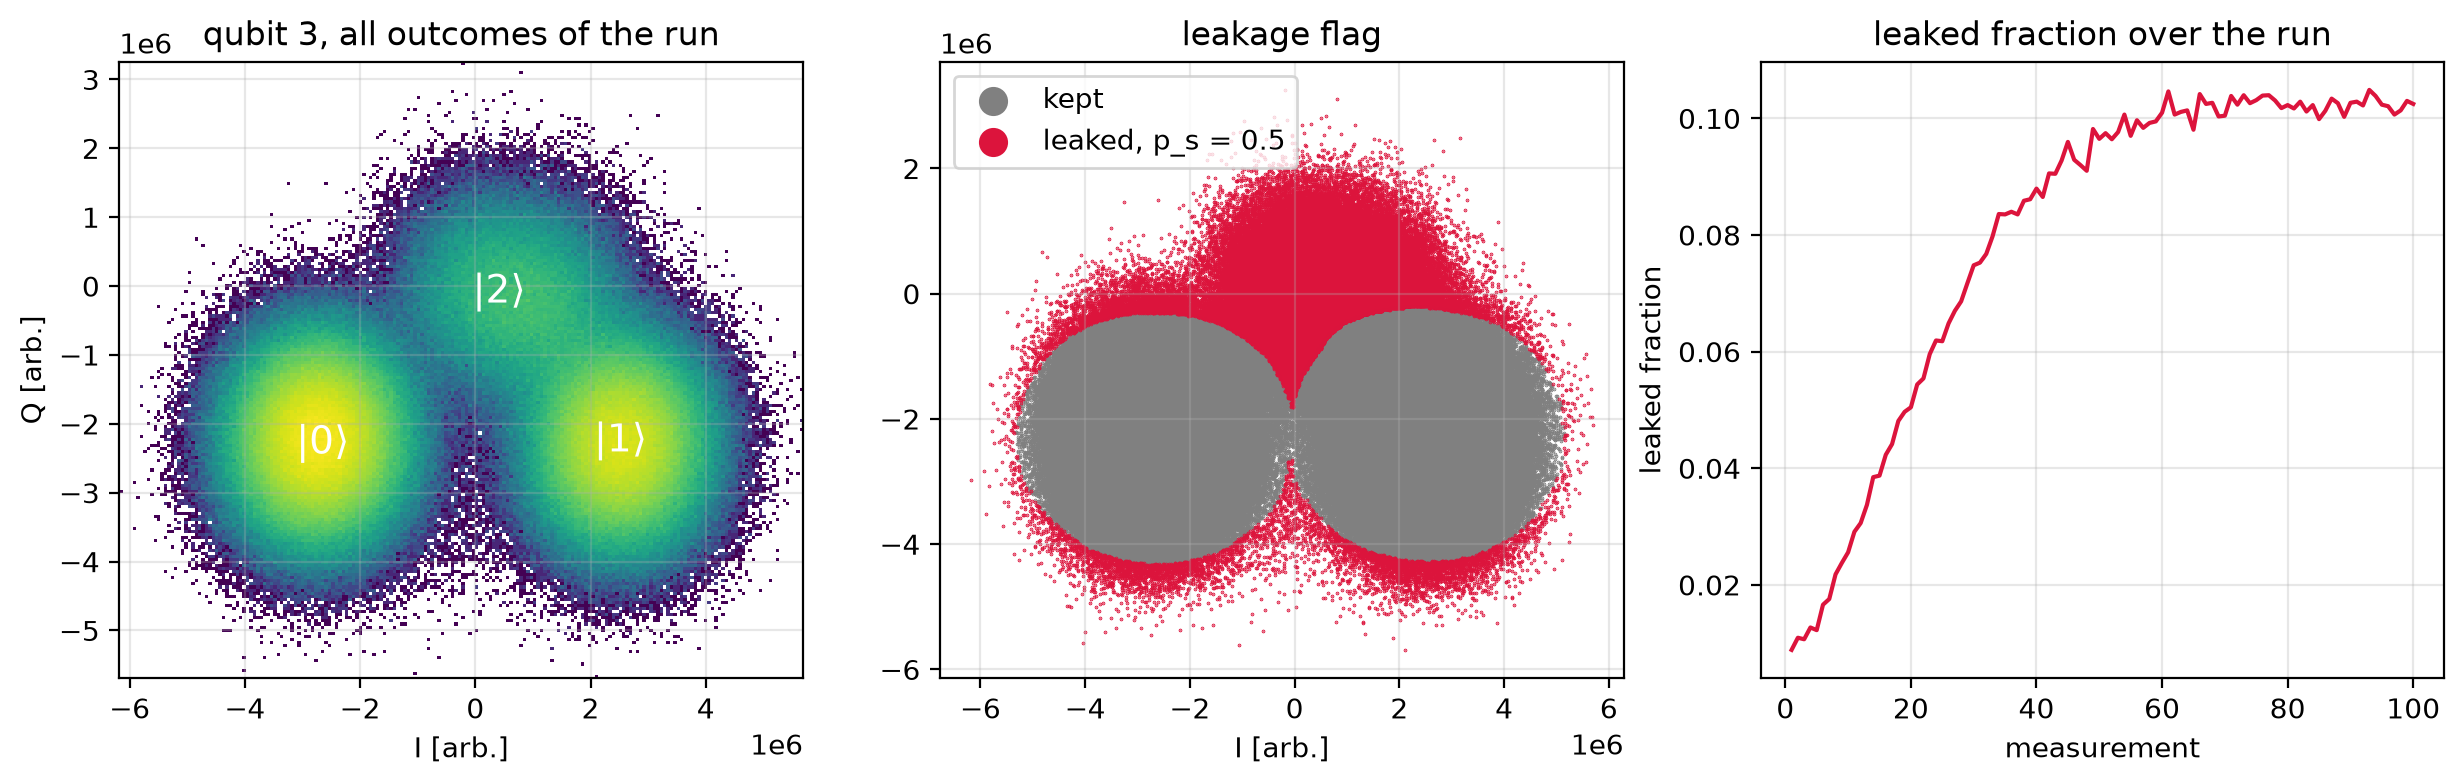

In [5]:
cal3 = postselect(*(unpack(f, f"cal_q3_{k}") for k in ("first0", "second0", "first1", "second1")))
readout3 = Readout(*cal3)
long_run = unpack(f, "exp_q3")
pts = long_run.ravel()
leaked = readout3.leaked(pts)
print(f"leaked: {leaked.mean():.1%} of all outcomes")

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist2d(pts.real, pts.imag, bins=200, norm="log", cmap="viridis")
for label, cloud in zip(("|0⟩", "|1⟩"), cal3):
    axs[0].annotate(label, (cloud.real.mean(), cloud.imag.mean()), color="w", fontsize=14, ha="center", va="center")
axs[0].annotate("|2⟩", (pts[leaked].real.mean(), pts[leaked].imag.mean()), color="w", fontsize=14, ha="center", va="center")
axs[0].set(title="qubit 3, all outcomes of the run", xlabel="I [arb.]", ylabel="Q [arb.]")
axs[1].scatter(pts[~leaked].real, pts[~leaked].imag, s=0.1, c="gray", rasterized=True, label="kept")
axs[1].scatter(pts[leaked].real, pts[leaked].imag, s=0.1, c="crimson", rasterized=True, label="leaked, p_s = 0.5")
axs[1].set(title="leakage flag", xlabel="I [arb.]")
axs[1].legend(markerscale=30, loc="upper left")
axs[2].plot(np.arange(1, long_run.shape[1] + 1), readout3.leaked(long_run).mean(0), color="crimson")
axs[2].set(title="leaked fraction over the run", xlabel="measurement", ylabel="leaked fraction");

## 2. The circuit

`repetition_code(d, T, xbasis, logical, noise)` builds a stim memory experiment as run on the device:
d code qubits, d − 1 ancillas, T rounds, ancillas never reset. Detectors are D_t = m_t ⊕ m_{t−2}, so a
soft flip (a wrong recorded bit with an intact qubit state) fires two detectors two rounds apart. Noise
is uniform circuit-level noise (`Noise`: two-qubit depolarizing, single-qubit gates, idling T1 and T2,
hard flips before each measurement).

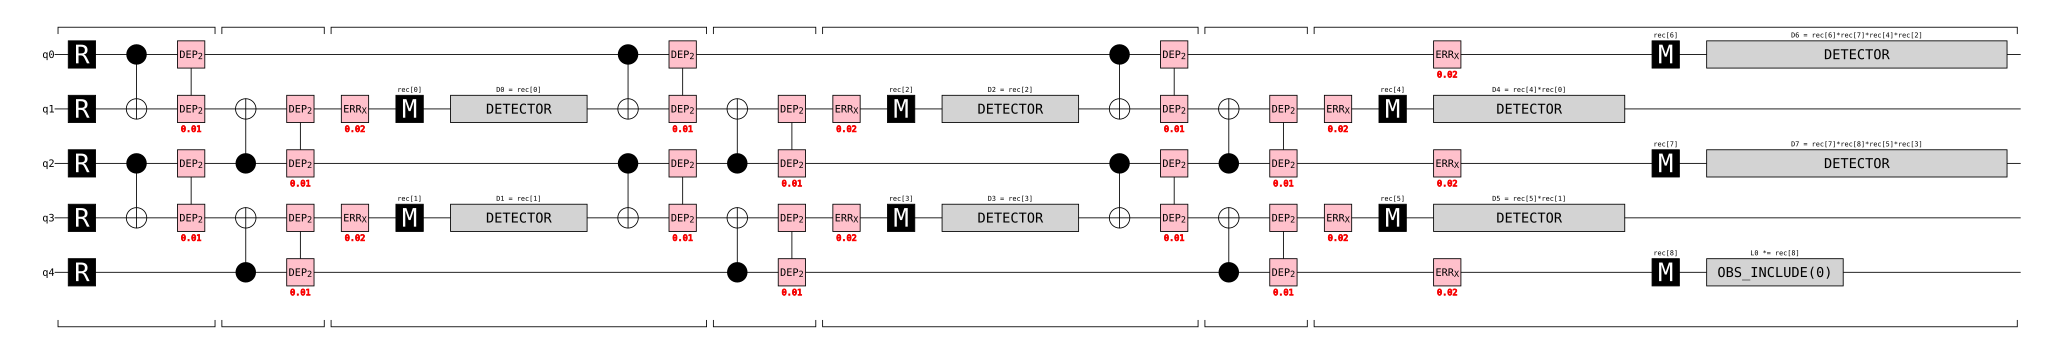

In [6]:
repetition_code(3, 3, noise=Noise(p2=0.01, p_hard=0.02)).diagram("timeline-svg")

## 3. Soft vs hard decoding

To compare decoders we need many shots where we know the true answer, so we simulate the device in
three steps.

1. **Qubits.** stim samples the repetition code under circuit-level noise with error rates of IBM
   Sherbrooke (gate errors, idling errors, hard flips before each measurement). The result is the
   bit each measured qubit actually ended up in, `true`.
2. **Readout.** Real hardware never hands us those bits, only IQ points. So for every true bit we draw
   a random IQ point from the measured calibration cloud of that state: a point of the |0⟩ cloud for a
   0, of the |1⟩ cloud for a 1. The clouds overlap, so some points land on the wrong side. Readout
   errors therefore appear exactly as often, and with the same shape, as on the real qubit.
3. **Jitter.** Each drawn point is shifted by a small Gaussian step (10 % of the cloud width). Without
   it the simulation would only ever produce the exact calibration points the readout model was fitted
   on, and the model would look more certain about them than it is about fresh measurements. The
   jitter turns the finite set of calibration points into a smooth distribution (a smoothed bootstrap,
   paper App. F).

Then `readout` turns each IQ point back into a measured bit z and its p_s, exactly as for hardware data.

In [7]:
NOISE = Noise(p2=0.0286, p1=0.00037, t1=0.0014, t2=0.0041, p_hard=0.0199)


def to_iq(bits):
    draw = np.where(bits, iq1[rng.integers(len(iq1), size=bits.shape)], iq0[rng.integers(len(iq0), size=bits.shape)])
    return draw + 0.1 * (rng.normal(0, both.real.std(), bits.shape) + 1j * rng.normal(0, both.imag.std(), bits.shape))


true = repetition_code(7, 10, noise=NOISE).compile_sampler(seed=0).sample(5000)
z, p = readout(to_iq(true))
print(f"{true.shape[0]} shots x {true.shape[1]} measurements, readout errors {(z != true).mean():.2%}, mean p_s {p.mean():.2%}")
print(f"mean p_s of correct outcomes {p[z == true].mean():.3f}, of wrong outcomes {p[z != true].mean():.3f}")

5000 shots x 67 measurements, readout errors 3.57%, mean p_s 5.45%
mean p_s of correct outcomes 0.046, of wrong outcomes 0.277


The last line is the point of soft information: wrong outcomes carry a much higher p_s than correct
ones, so the decoder can tell which bits to distrust.

**Decoding.** `SoftMatcher(circuit)` builds the matching graph (detectors as nodes, possible errors as
edges weighted by their probability). A readout error on one measurement flips a known pair of
detectors, so each measurement has one edge for it. We compare two decoders on the same shots:

- **soft** (`decode_soft`): for every shot, the weight of each measurement's edge uses that
  measurement's own p_s. A confident outcome barely changes the graph, an ambiguous one makes a readout
  error there cheap to explain.
- **hard** (`decode_static`): one graph for all shots, every measurement gets the same p_s (the average
  readout error, as a calibrated hard decoder would use).

In [8]:
def decode(d, T=10, shots=5000):
    circuit = repetition_code(d, T, noise=NOISE)
    z, p = readout(to_iq(circuit.compile_sampler(seed=d).sample(shots)))
    m, n = SoftMatcher(circuit), p.shape[1]
    return z, p, m, {"soft": m.decode_soft(z, p).mean(),
                     "hard": m.decode_static(z, np.full(n, p.mean())).mean()}


start = time.time()
z, p, m, rates = decode(7)
print(f"d = 7, T = 10, 5000 shots in {time.time() - start:.1f} s")
for k, v in rates.items():
    print(f"{k:14s} logical error {v:.4f}")

d = 7, T = 10, 5000 shots in 0.5 s
soft           logical error 0.0134
hard           logical error 0.0198


Over distance, soft decoding suppresses errors faster: the gap grows with d.

,soft,hard
3,0.06610,0.07950
5,0.02700,0.03595
7,0.01045,0.01575
9,0.00310,0.00715
11,0.00150,0.00290


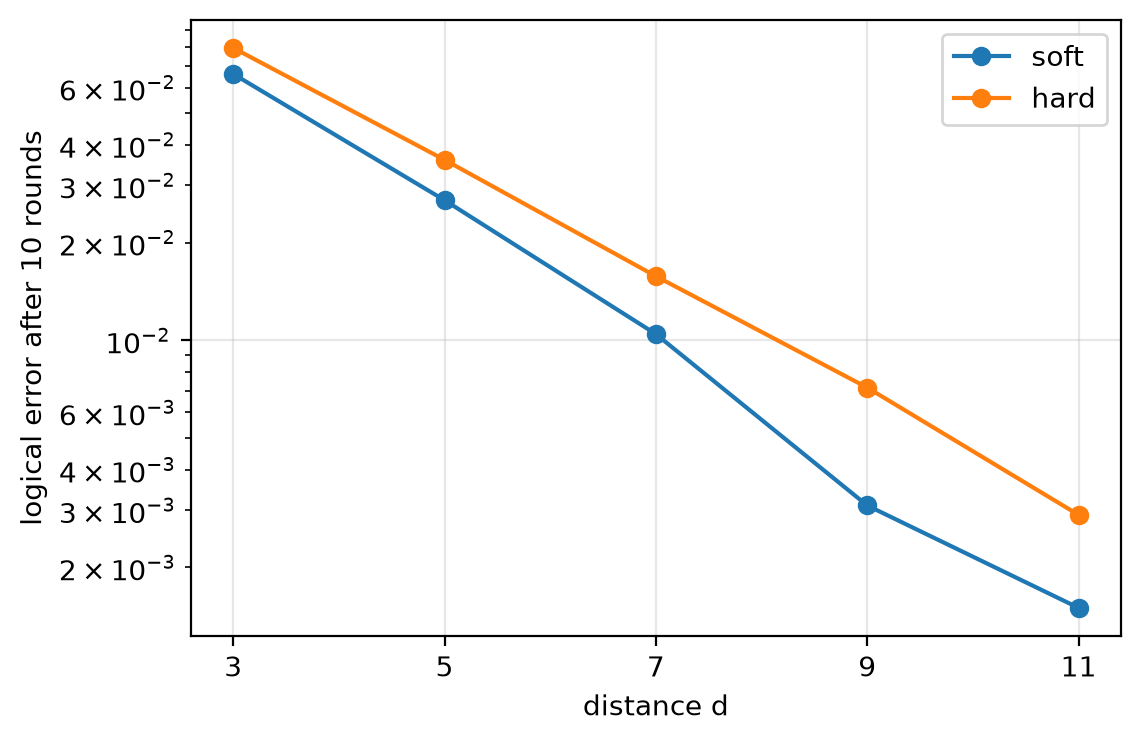

In [9]:
ds = [3, 5, 7, 9, 11]
sweep = pd.DataFrame([decode(d, shots=20000)[3] for d in ds], index=ds)
ax = sweep.plot(marker="o", logy=True, figsize=(6, 4))
ax.set(xlabel="distance d", ylabel="logical error after 10 rounds", xticks=ds)
sweep

## 4. How many bits of p_s?

Real-time decoders cannot afford 64-bit weights. `truncate(p, b)` rounds p_s to 2ᵇ levels on [0, 0.5].
A few bits already recover most of the soft gain.

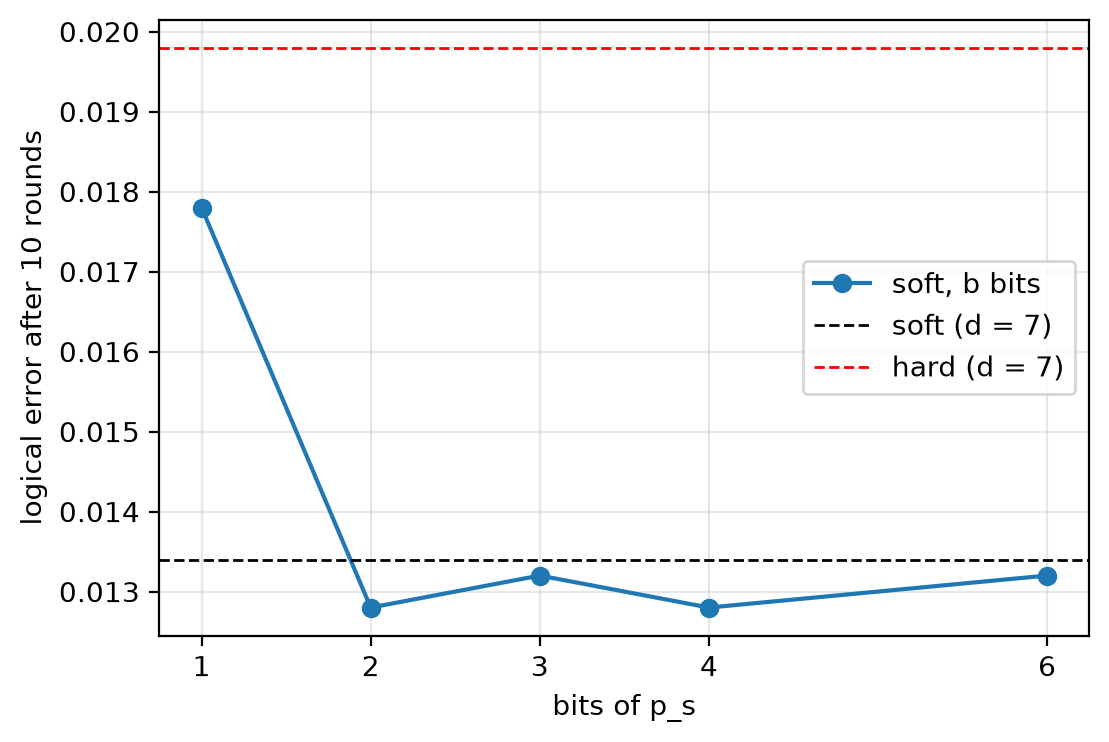

In [10]:
bits = [1, 2, 3, 4, 6]
by_bits = pd.Series({b: m.decode_soft(z, truncate(p, b)).mean() for b in bits})
ax = by_bits.plot(marker="o", figsize=(6, 4), label="soft, b bits")
for k in ("soft", "hard"):
    ax.axhline(rates[k], ls="--", color="k" if k == "soft" else "r", lw=1, label=f"{k} (d = 7)")
ax.set(xlabel="bits of p_s", ylabel="logical error after 10 rounds", xticks=bits)
ax.legend();

## 5. The hardware results

`data/results.csv.gz` holds the logical error counts of all 554 hardware jobs as decoded for the paper
(sub-chains of a 52-qubit chain on IBM Sherbrooke). Per-round logical error ε (Eq. 10) falls as
ε ∝ Λ^−(d+1)/2; soft decoding increases Λ. `make figures` reproduces every figure and Table I.

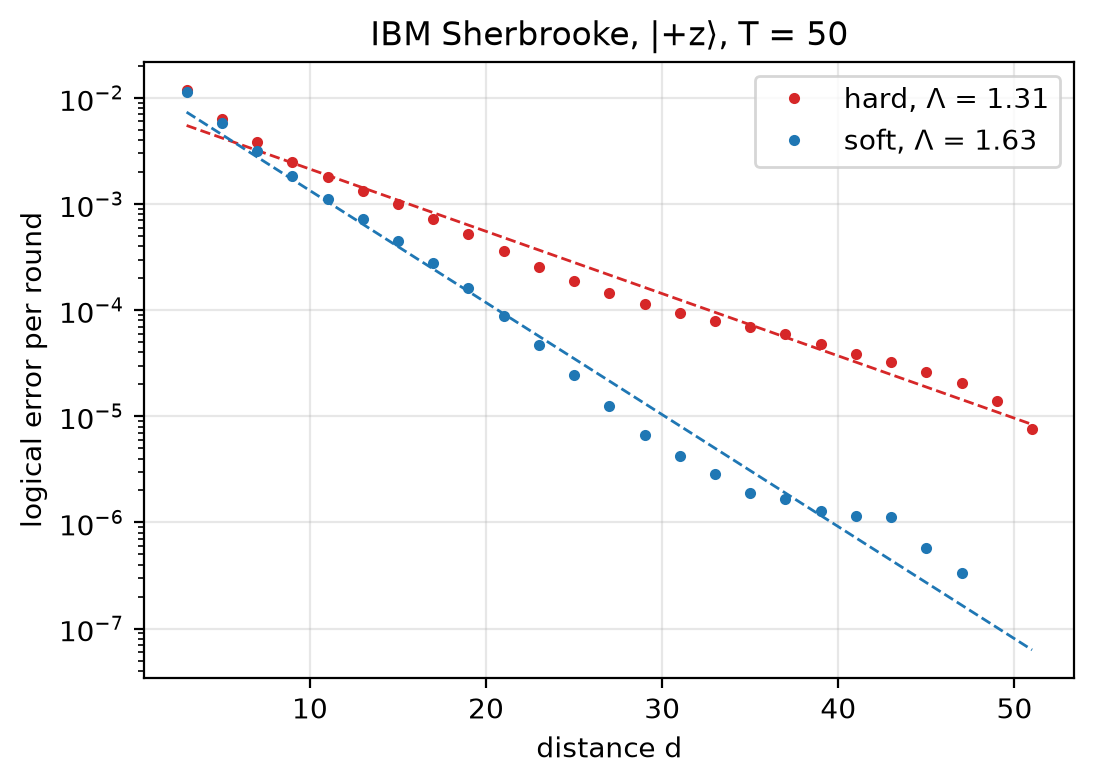

In [11]:
res = pd.read_csv("../data/results.csv.gz")
T = 50
fig, ax = plt.subplots(figsize=(6, 4))
for method, color in (("hard", "C3"), ("soft", "C0")):
    x = res.query("experiment == 'hw' and state == 'Z0' and T == @T and bits == 64 and method == @method")
    x = x.groupby("d")[["shots", "errors"]].sum()
    eps = 0.5 * (1 - (1 - 2 * x.errors / x.shots) ** (1 / T))
    ok = x.errors > 5
    slope, c = np.polyfit((x.index[ok] + 1) / 2, np.log10(eps[ok]), 1)
    ax.semilogy(x.index, eps, "o", color=color, ms=3, label=f"{method}, Λ = {10 ** -slope:.2f}")
    ax.semilogy(x.index, 10 ** (c + slope * (x.index + 1) / 2), "--", color=color, lw=1)
ax.set(xlabel="distance d", ylabel="logical error per round", title="IBM Sherbrooke, |+z⟩, T = 50")
ax.legend();

## Using the raw data

With the raw IQ archive unpacked to `data/raw` (`make data`), any job decodes in a few lines;
`scripts/rerun.py` does this for all jobs and writes counts in the format of `results.csv.gz`.

```python
from softinfo import Noise, decode_subsets
from softinfo.data import load_calibration, load_job, manifest, soft_info

job = manifest()["hardware"][0]
iq, qubits, T = load_job(job["job"])
z, p = soft_info(iq, qubits, load_calibration(*job["calib"]))
errors, samples = decode_subsets(z, p, T, job["state"][0] == "X", int(job["state"][1]),
                                 Noise.from_list(job["noise_list"]), distances=[3, 5, 7])
```